# 🧬 MERFISH pipeline — runnable synthetic demo

The production notebooks need Vizgen MERSCOPE data from private S3/GCS buckets, so this
notebook builds a small **synthetic** spatial-transcriptomics dataset and runs the *exact*
Scanpy pipeline the real notebooks use — `normalize_total → log1p → scale → PCA → neighbors
→ UMAP → Leiden` — then adds a **squidpy** spatial-neighborhood analysis, end to end, with
real computed figures.

> Data is simulated; the **pipeline and plots are real**. See `scripts/demo_pipeline.py`
> for the version that also renders the cluster-marker heatmap.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

sc.settings.verbosity = 1
RNG = np.random.default_rng(0)

## 1 · Simulate 3,000 cells across 6 spatial cell-type domains
Each domain occupies a region of tissue and expresses its own marker-gene program
on top of a shared low background.

In [2]:
N_CELLS, N_GENES, K, MARKERS_PER = 3000, 60, 6, 8
domain = RNG.integers(0, K, size=N_CELLS)
lib = RNG.lognormal(0.0, 0.35, size=N_CELLS)                  # per-cell sequencing depth
marker_of = {k: np.arange(k * MARKERS_PER, (k + 1) * MARKERS_PER) for k in range(K)}

rate = np.full((N_CELLS, N_GENES), 0.3)                       # background
for c in range(N_CELLS):
    rate[c, marker_of[domain[c]]] += RNG.uniform(6, 14)       # marker program
counts = RNG.poisson(rate * lib[:, None]).astype(np.float32)

centers = RNG.uniform(0, 40, size=(K, 2))                     # domain centers in tissue
spatial = centers[domain] + RNG.normal(0, 3.2, size=(N_CELLS, 2))

ad = sc.AnnData(
    counts,
    obs=pd.DataFrame(index=[f"cell{i}" for i in range(N_CELLS)]),
    var=pd.DataFrame(index=[f"g{j:02d}" for j in range(N_GENES)]),
)
ad.obsm["spatial"] = spatial
ad

AnnData object with n_obs × n_vars = 3000 × 60
    obsm: 'spatial'

## 2 · Standard Scanpy pipeline (same calls as the real notebooks)

In [3]:
sc.pp.normalize_total(ad, target_sum=1e4)
sc.pp.log1p(ad)
ad.raw = ad
sc.pp.scale(ad, max_value=10)
sc.tl.pca(ad, svd_solver="arpack", n_comps=30)
sc.pp.neighbors(ad, n_neighbors=15, n_pcs=30)
sc.tl.umap(ad)
sc.tl.leiden(ad, resolution=1.0)
print(f"Leiden found {ad.obs['leiden'].nunique()} clusters from {K} simulated domains")

/private/tmp/merfish_sq_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/nz/bflkqyd52d99dwhykqmt0mbw0000gp/T/ipykernel_87613/465518428.py:8: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(ad, resolution=1.0)


Leiden found 6 clusters from 6 simulated domains


## 3 · Visualize — UMAP and tissue space, colored by Leiden cluster

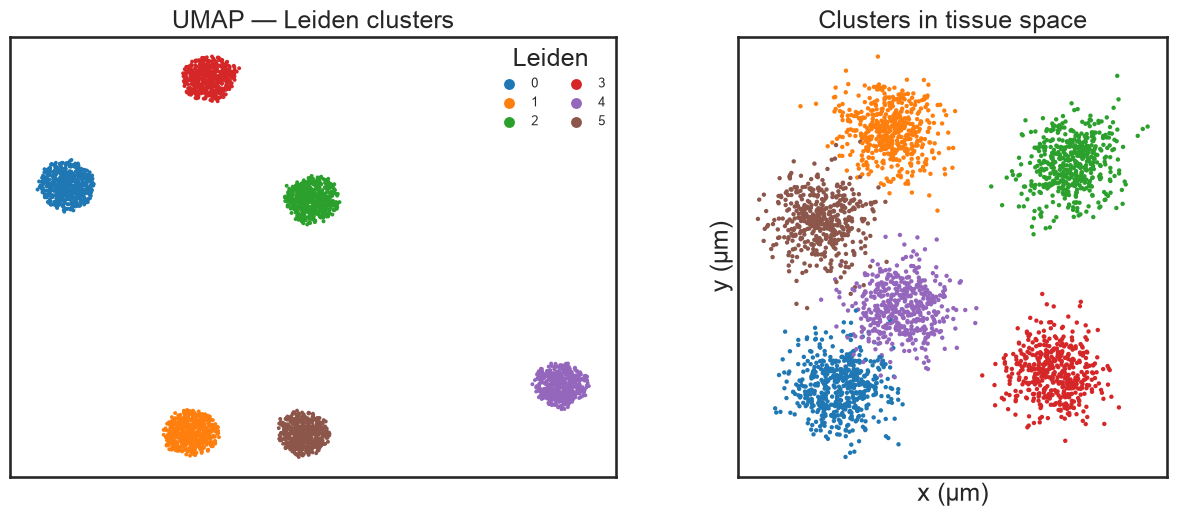

In [4]:
sns.set_theme(style="white", context="talk")
cats = sorted(ad.obs["leiden"].cat.categories, key=int)
pal = sns.color_palette("tab10", len(cats))
cmap = {c: pal[i] for i, c in enumerate(cats)}
colors = np.array([cmap[v] for v in ad.obs["leiden"].astype(str)])

fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 5.5))
a0.scatter(*ad.obsm["X_umap"].T, c=colors, s=8, lw=0)
a0.set(title="UMAP — Leiden clusters", xticks=[], yticks=[])
a1.scatter(*ad.obsm["spatial"].T, c=colors, s=10, lw=0)
a1.set_aspect("equal")
a1.set(title="Clusters in tissue space", xlabel="x (µm)", ylabel="y (µm)",
       xticks=[], yticks=[])
for c in cats:
    a0.scatter([], [], c=[cmap[c]], s=40, label=c)
a0.legend(title="Leiden", frameon=False, ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## 4 · A modern extension — spatial neighborhood enrichment (squidpy)
Plain Scanpy clusters in expression space only. **squidpy** adds spatial-aware
analysis: build a spatial graph from cell coordinates, then test which cluster
pairs sit next to each other more (or less) often than chance — the
`nhood_enrichment` z-score. This is the kind of question MERFISH's spatial
coordinates uniquely let you ask.

INFO     Creating graph using `None` transform and `1` libraries.                                                  


/private/tmp/merfish_sq_env/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/private/tmp/merfish_sq_env/lib/python3.14/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/var/folders/nz/bflkqyd52d99dwhykqmt0mbw0000gp/T/ipykernel_87613/1204580890.py:4: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(ad, coord_type="generic", n_neighs=6)


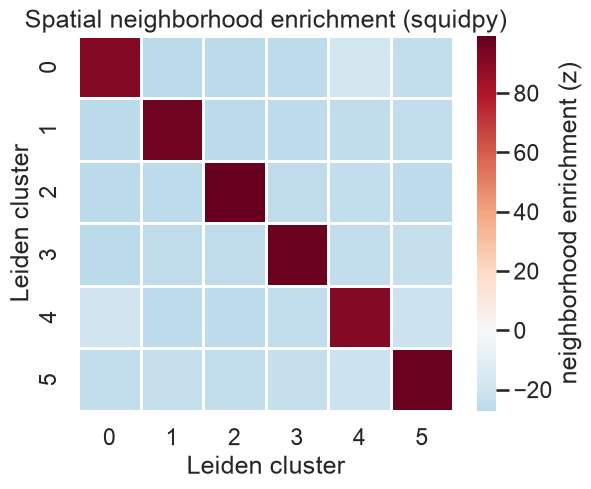

In [5]:
import squidpy as sq

ad.obs["leiden"] = ad.obs["leiden"].astype("category")
sq.gr.spatial_neighbors(ad, coord_type="generic", n_neighs=6)
sq.gr.nhood_enrichment(ad, cluster_key="leiden", seed=0, show_progress_bar=False)

z = ad.uns["leiden_nhood_enrichment"]["zscore"]
fig, ax = plt.subplots(figsize=(6.4, 5.2))
sns.heatmap(z, cmap="RdBu_r", center=0, square=True, linewidths=1, linecolor="white",
            xticklabels=cats, yticklabels=cats,
            cbar_kws={"label": "neighborhood enrichment (z)"}, ax=ax)
ax.set(title="Spatial neighborhood enrichment (squidpy)",
       xlabel="Leiden cluster", ylabel="Leiden cluster")
plt.tight_layout()
plt.savefig("../assets/demo_spatial_squidpy.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()
# Spatially segregated domains -> strong positive self-enrichment (diagonal),
# negative cross-enrichment off-diagonal.